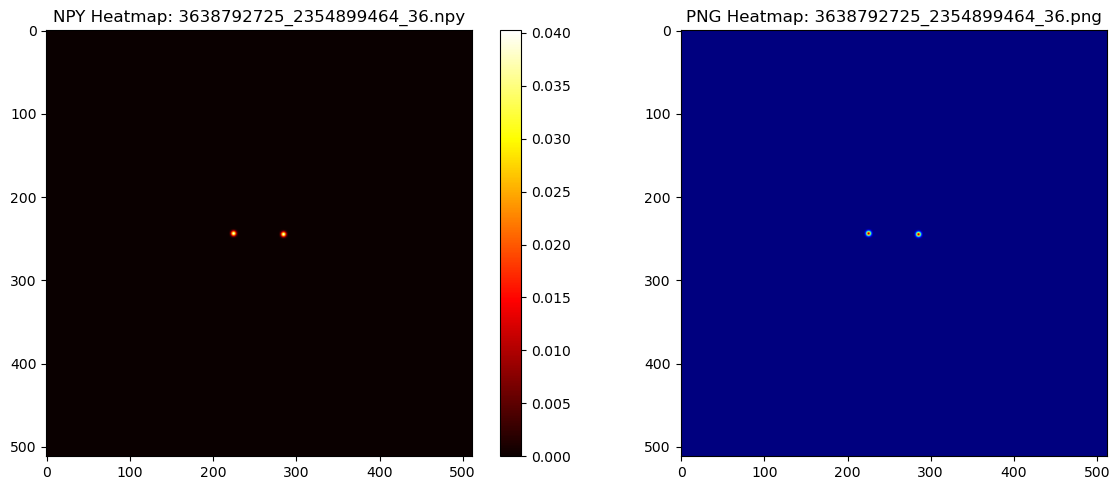

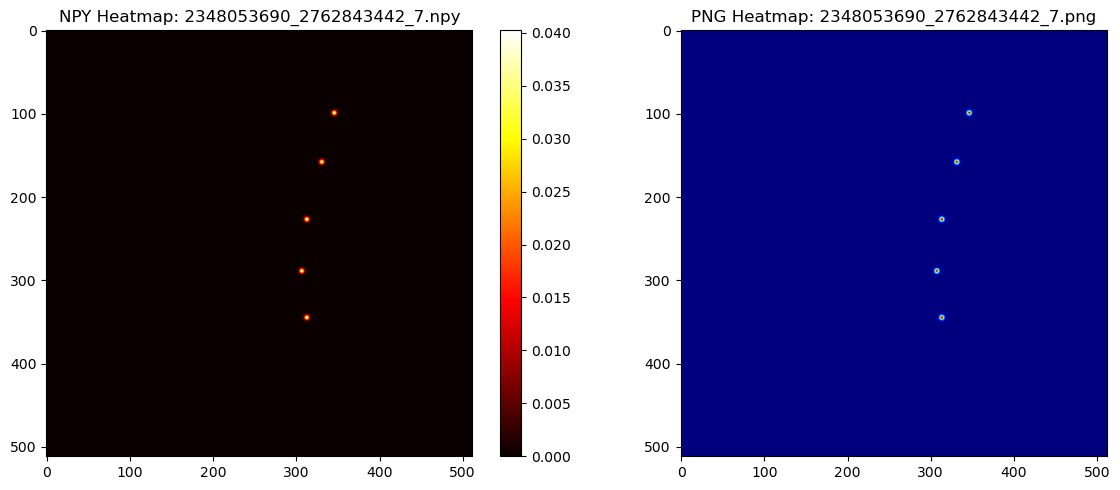

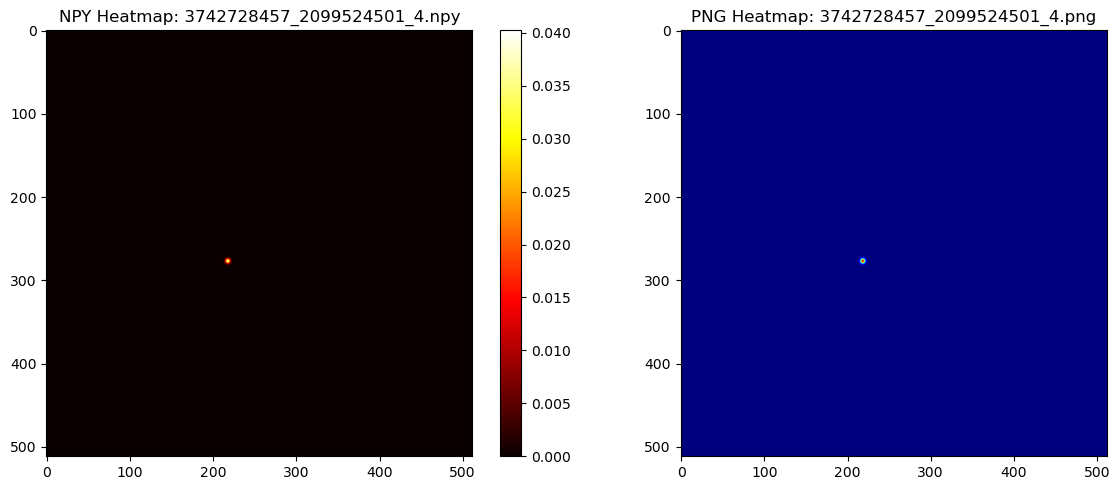

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def validate_heatmaps(heatmap_dir="heatmaps", n=5):
    npy_files = sorted([f for f in os.listdir(heatmap_dir) if f.endswith(".npy")])
    png_files = sorted([f for f in os.listdir(heatmap_dir) if f.endswith(".png")])
    
    assert len(npy_files) == len(png_files), "PNG와 NPY 개수가 다릅니다!"

    sampled = np.random.choice(npy_files, min(n, len(npy_files)), replace=False)
    
    for file in sampled:
        npy_path = os.path.join(heatmap_dir, file)
        png_path = os.path.join(heatmap_dir, file.replace(".npy", ".png"))

        try:
            heatmap_npy = np.load(npy_path)
            heatmap_png = np.array(Image.open(png_path).convert("RGB"))
        except Exception as e:
            print(f"{file} 로딩 오류: {e}")
            continue

        # 시각적으로 비교
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(heatmap_npy, cmap="hot")
        plt.title(f"NPY Heatmap: {file}")
        plt.colorbar()

        plt.subplot(1, 2, 2)
        plt.imshow(heatmap_png)
        plt.title(f"PNG Heatmap: {file.replace('.npy', '.png')}")

        plt.tight_layout()
        plt.show()

validate_heatmaps("heatmaps", n=3)


In [3]:
import os
import numpy as np

def check_npy_heatmap_validity(heatmap_dir="heatmaps", threshold=1e-3):
    npy_files = sorted([f for f in os.listdir(heatmap_dir) if f.endswith(".npy")])
    empty_maps = []

    for file in npy_files:
        npy_path = os.path.join(heatmap_dir, file)
        heatmap = np.load(npy_path)

        nonzero_count = np.count_nonzero(heatmap > threshold)
        if nonzero_count == 0:
            empty_maps.append(file)

    print(f"총 {len(empty_maps)}개의 히트맵에서 유의미한 픽셀이 없습니다.")
    if empty_maps:
        print("예시:", empty_maps[:5])

check_npy_heatmap_validity("heatmaps")


총 0개의 히트맵에서 유의미한 픽셀이 없습니다.


In [7]:
# UNet이 예측한 마스크(pred_mask)가 원본 이미지나 히트맵과 잘 맞는지 확인
import torch
import cv2

# 테스트용 이미지 하나 불러오기
image_path = "heatmaps/50000_30011_47.png"
heatmap_path = "heatmaps/50000_30011_47.npy"
mask_path = "masks/50000_30011_47.npy"

# 이미지 불러오기 및 모델 추론
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) / 255.0
image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).cuda()

model.eval()
with torch.no_grad():
    pred_mask = model(image_tensor).cpu().numpy()

compare_heatmap_and_mask(image_path, heatmap_path, pred_mask)


[ WARN:0@25370.150] global loadsave.cpp:268 findDecoder imread_('heatmaps/50000_30011_47.png'): can't open/read file: check file path/integrity


TypeError: unsupported operand type(s) for /: 'NoneType' and 'float'

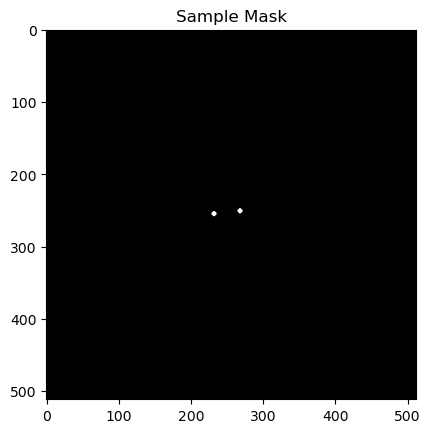

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mask = np.load("masks/100206310_1012284084_10.npy")
plt.imshow(mask, cmap='gray')
plt.title("Sample Mask")
plt.show()


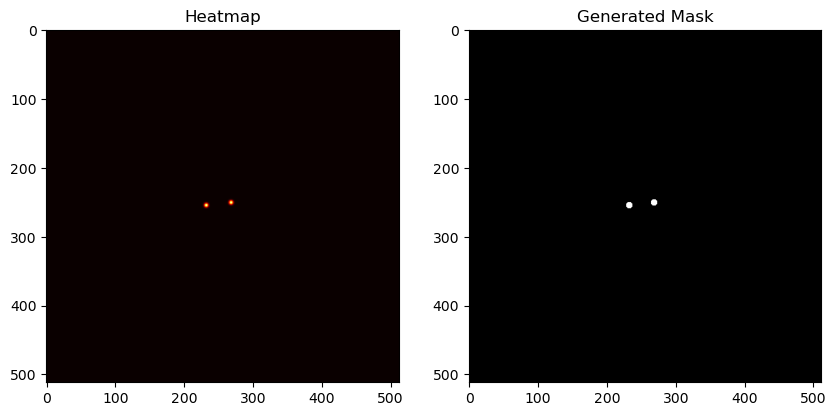

In [9]:
# 확인용 예시
import matplotlib.pyplot as plt
import numpy as np

heatmap = np.load("heatmaps/100206310_1012284084_10.npy")
mask = np.load("masks/100206310_1012284084_10.npy")

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(heatmap, cmap='hot')
axs[0].set_title("Heatmap")
axs[1].imshow(mask, cmap='gray')
axs[1].set_title("Generated Mask")
plt.show()


In [10]:
mask_dir = "masks"
sizes = []
for file in os.listdir(mask_dir):
    if file.endswith(".npy"):
        mask = np.load(os.path.join(mask_dir, file))
        sizes.append(np.sum(mask))

print(f"평균 마스크 크기 (활성 픽셀 수): {np.mean(sizes):.2f}")


평균 마스크 크기 (활성 픽셀 수): 163.22


In [12]:
import pandas as pd

# 등급을 숫자로 매핑
label_map = {
    'Normal/Mild': 0,
    'Moderate': 1,
    'Severe': 2
}

# CSV 로드
train_df = pd.read_csv("rsna_2024_spine/train.csv")  # study_id 기준 등급 정보
prop_df = pd.read_csv("propagated_labels.csv")  # study_id, series_id, instance_number, x, y, level

# 질병 이름 추출 (train.csv에서 study_id를 제외한 나머지 25개 열)
disease_cols = train_df.columns[1:]

# study_id를 기준으로 label 매핑
train_df_encoded = train_df.copy()
for col in disease_cols:
    train_df_encoded[col] = train_df[col].map(label_map)

# slice마다 25개 질병에 대해 라벨 지정
output_rows = []

for _, row in prop_df.iterrows():
    study_id = int(row["study_id"])
    series_id = int(row["series_id"])
    instance_number = int(row["instance_number"])

    if study_id in train_df_encoded["study_id"].values:
        label_row = train_df_encoded[train_df_encoded["study_id"] == study_id][disease_cols].values[0]
        output_rows.append({
            "study_id": study_id,
            "series_id": series_id,
            "instance_number": instance_number,
            **{disease_cols[i]: label_row[i] for i in range(len(disease_cols))}
        })

# DataFrame으로 변환
slice_df = pd.DataFrame(output_rows)

# 저장
slice_df.to_csv("slice_level_labeled.csv", index=False)
print("✅ slice_level_labeled.csv 저장 완료!")


✅ slice_level_labeled.csv 저장 완료!


In [14]:
import pandas as pd

df = pd.read_csv("slice_level_labeled.csv")
valid_label_count = 0

for col in df.columns:
    if col not in ['study_id', 'series_id']:
        valid_label_count += df[col].notna().sum()

print(f"전체 유효 라벨 수: {valid_label_count}")
print(f"전체 슬라이스 수: {len(df)} x 25 = {len(df) * 25}")


전체 유효 라벨 수: 14728232
전체 슬라이스 수: 570886 x 25 = 14272150


In [15]:
df = pd.read_csv("slice_level_labeled.csv")
print(df.iloc[0])


study_id                                    4003253.0
series_id                                 702807833.0
instance_number                                   1.0
spinal_canal_stenosis_l1_l2                       0.0
spinal_canal_stenosis_l2_l3                       0.0
spinal_canal_stenosis_l3_l4                       0.0
spinal_canal_stenosis_l4_l5                       0.0
spinal_canal_stenosis_l5_s1                       0.0
left_neural_foraminal_narrowing_l1_l2             0.0
left_neural_foraminal_narrowing_l2_l3             0.0
left_neural_foraminal_narrowing_l3_l4             0.0
left_neural_foraminal_narrowing_l4_l5             1.0
left_neural_foraminal_narrowing_l5_s1             0.0
right_neural_foraminal_narrowing_l1_l2            0.0
right_neural_foraminal_narrowing_l2_l3            0.0
right_neural_foraminal_narrowing_l3_l4            1.0
right_neural_foraminal_narrowing_l4_l5            1.0
right_neural_foraminal_narrowing_l5_s1            0.0
left_subarticular_stenosis_l

In [16]:
import pandas as pd

df = pd.read_csv("slice_level_labeled.csv")
print("총 슬라이스 수:", len(df))
print("고유한 study_id 수:", df["study_id"].nunique())
print("고유한 series_id 수:", df["series_id"].nunique())


총 슬라이스 수: 570886
고유한 study_id 수: 1011
고유한 series_id 수: 3220


In [17]:
# 라벨 칼럼만 추출
disease_cols = df.columns.difference(['study_id', 'series_id', 'instance_number'])
contains_negative = (df[disease_cols] == -1).any(axis=1).sum()

print(f"-1(라벨 없음) 값이 있는 슬라이스 수: {contains_negative}")


-1(라벨 없음) 값이 있는 슬라이스 수: 0


In [24]:
slice_counts = df.groupby(["study_id", "series_id"]).size()
print("슬라이스 개수 평균:", slice_counts.mean())
print("슬라이스 개수 최소~최대:", slice_counts.min(), "~", slice_counts.max())

df = pd.read_csv("slice_level_labeled.csv")
valid_count = df.drop(columns=["study_id", "series_id", "instance_number"]).ne(-1).any(axis=1).sum()
print(f"라벨이 하나라도 존재하는 유효 슬라이스 수: {valid_count}")



슬라이스 개수 평균: 177.29378881987577
슬라이스 개수 최소~최대: 10 ~ 1670
라벨이 하나라도 존재하는 유효 슬라이스 수: 570886


In [23]:
import os
import pandas as pd

# 파일 경로 설정
csv_path = "slice_level_labeled.csv"
image_dir = "rsna_2024_spine/train_images"
heatmap_dir = "heatmaps"
coord_dir = "heatmaps"
segmask_dir = "masks"

df = pd.read_csv(csv_path)
num_slices = 25

invalid_slice_count = 0

for idx, row in df.iterrows():
    study_id = int(row["study_id"])
    series_id = int(row["series_id"])

    for i in range(num_slices):
        img_path = os.path.join(image_dir, f"{study_id}_{series_id}_slice_{i:02d}.png")
        heatmap_path = os.path.join(heatmap_dir, f"{study_id}_{series_id}_slice_{i:02d}.png")
        coord_path = os.path.join(coord_dir, f"{study_id}_{series_id}_{i}.npy")
        seg_path = os.path.join(segmask_dir, f"{study_id}_{series_id}_slice_{i:02d}.png")

        if not (os.path.exists(img_path) and os.path.exists(heatmap_path) and 
                os.path.exists(coord_path) and os.path.exists(seg_path)):
            invalid_slice_count += 1

print(f"❌ 유효하지 않은 슬라이스 수: {invalid_slice_count}")


❌ 유효하지 않은 슬라이스 수: 14272150


In [27]:
import os
import numpy as np
import cv2
from scipy.ndimage import maximum_filter

input_dir = "heatmaps"
output_dir = "coords"
os.makedirs(output_dir, exist_ok=True)

def extract_coords_from_heatmap(heatmap):
    coords = []
    for _ in range(25):  # 최대 25개 좌표 추출
        y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
        if heatmap[y, x] < 1e-2:
            break
        coords.append((x, y))
        heatmap[max(0, y-10):y+10, max(0, x-10):x+10] = 0
    return np.array(coords)

for fname in os.listdir(input_dir):
    if not fname.endswith(".npy"):
        continue
    heatmap_path = os.path.join(input_dir, fname)
    heat = np.load(heatmap_path)

    coords = extract_coords_from_heatmap(heat.copy())
    if coords.shape[0] > 0:
        base = fname.replace(".npy", "")
        save_path = os.path.join(output_dir, base + ".npy")
        np.save(save_path, coords)

print("✅ heatmap 기반 coords 추출 완료")


✅ heatmap 기반 coords 추출 완료


In [26]:
import os
import pandas as pd

df = pd.read_csv("slice_level_labeled.csv")

# coords npy 파일이 있는지 확인
def has_coord(row):
    path = f"heatmaps/{row['study_id']}_{row['series_id']}_{row['instance_number']}.npy"
    return os.path.exists(path)

df["has_coord"] = df.apply(has_coord, axis=1)
df_filtered = df[df["has_coord"] == True].drop(columns=["has_coord"])

df_filtered.to_csv("slice_level_labeled_with_coords.csv", index=False)
print(f"✅ coords 있는 슬라이스만 추출 완료: {len(df_filtered)}개")


✅ coords 있는 슬라이스만 추출 완료: 0개


In [ ]:
# attetnion 방식별 AUC & Loss 시각화
import numpy as np
import matplotlib.pyplot as plt

models = ["seg", "heat", "fusion"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # 파란, 주황, 초록

plt.figure(figsize=(12, 5))

# 📈 Train Loss
plt.subplot(1, 2, 1)
for model, color in zip(models, colors):
    losses = np.load(f"results/{model}_train_loss.npy")
    plt.plot(losses, label=f"{model} attention", color=color)
plt.title("Train Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# 📈 Validation AUC
plt.subplot(1, 2, 2)
for model, color in zip(models, colors):
    aucs = np.load(f"results/{model}_val_auc.npy")
    plt.plot(aucs, label=f"{model} attention", color=color)
plt.title("Validation AUC per Epoch")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [28]:
import torch
import numpy as np
from torch.utils.data import DataLoader
import torch.nn as nn
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import cv2

# UNet 클래스 정의 (학습 때와 동일하게!)
class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()
        def CBR(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            )
        self.enc1 = nn.Sequential(CBR(1, 64), CBR(64, 64))
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(CBR(64, 128), CBR(128, 128))
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(CBR(128, 256), CBR(256, 256))
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = nn.Sequential(CBR(256, 128), CBR(128, 64))
        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec1 = nn.Sequential(CBR(128, 64), CBR(64, 32))
        self.final = nn.Conv2d(32, 1, kernel_size=1)
    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        bottleneck = self.bottleneck(self.pool2(enc2))
        dec2 = self.up2(bottleneck)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)
        dec1 = self.up1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)
        return torch.sigmoid(self.final(dec1))

# 평가 함수
def dice_score(pred, target, eps=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()
    return (2. * intersection + eps) / (union + eps)

def iou_score(pred, target, eps=1e-6):
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + eps) / (union + eps)

# 이미지/마스크 로딩 및 평가
model = UNet()
model.load_state_dict(torch.load("segmentation_model.pth", map_location="cpu"))
model.eval()

image_dir = "heatmaps"
mask_dir = "masks"
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".png")])

dice_scores = []
iou_scores = []

for file in tqdm(image_files):
    img_path = os.path.join(image_dir, file)
    mask_path = os.path.join(mask_dir, file.replace(".png", ".npy"))

    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) / 255.0
    image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,H,W)

    with torch.no_grad():
        pred = model(image_tensor)
        pred_mask = (pred > 0.5).float().squeeze().numpy()

    true_mask = np.load(mask_path)
    dice = dice_score(torch.tensor(pred_mask), torch.tensor(true_mask))
    iou = iou_score(torch.tensor(pred_mask), torch.tensor(true_mask))

    dice_scores.append(dice.item())
    iou_scores.append(iou.item())

# 최종 평균
print(f"🧪 평균 Dice Score: {np.mean(dice_scores):.4f}")
print(f"🧪 평균 IoU Score: {np.mean(iou_scores):.4f}")


100%|██████████| 145537/145537 [14:16:07<00:00,  2.83it/s]  

🧪 평균 Dice Score: 1.0000
🧪 평균 IoU Score: 1.0000


In [29]:
print("pred unique:", np.unique(pred_mask))
print("true unique:", np.unique(true_mask))
print("pred == ture:", np.all(pred_mask == true_mask))

pred unique: [0. 1.]
true unique: [0 1]
pred == ture: True


In [30]:
import pandas as pd

# CSV 경로에 맞게 조정
df = pd.read_csv("slice_level_labeled_filtered.csv")

# 라벨이 있는 열만 추출
label_cols = df.columns.difference(["study_id", "series_id", "instance_number"])

# 유효한 라벨 개수 계산
df["valid_label_count"] = (df[label_cols] != -1).sum(axis=1)

# 유효한 슬라이스만 필터링
valid_df = df[df["valid_label_count"] > 0]

# 개수 확인
print(f"전체 슬라이스 수: {len(df)}")
print(f"유효한 라벨이 있는 슬라이스 수: {len(valid_df)}")

# 분포 보기
print(valid_df["valid_label_count"].value_counts().sort_index())


전체 슬라이스 수: 570886
유효한 라벨이 있는 슬라이스 수: 570886
valid_label_count
25    570886
Name: count, dtype: int64


In [31]:
import pandas as pd
import os

df = pd.read_csv("slice_level_labeled_final.csv")
coord_dir = "coords"

# 1. 좌표 파일 존재 여부
df["coord_exists"] = df.apply(lambda row: os.path.exists(
    os.path.join(coord_dir, f"{int(row['study_id'])}_{int(row['series_id'])}_{int(row['instance_number'])}.npy")
), axis=1)

# 2. 유효한 라벨 존재 여부
label_cols = df.columns.difference(["study_id", "series_id", "instance_number"])
df["valid_label"] = df[label_cols].apply(lambda row: any(row != -1), axis=1)

# 3. 최종 학습 대상 필터링
final_df = df[df["coord_exists"] & df["valid_label"]]
print(f"✅ 최종 학습 가능 샘플 수: {len(final_df)}")


✅ 최종 학습 가능 샘플 수: 570886


In [32]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

df = pd.read_csv("slice_level_labeled_filtered.csv")
label_cols = df.columns.difference(["study_id", "series_id", "instance_number"])

# 시리즈별로 하나라도 유효한 라벨이 있고, 해당 좌표 파일이 존재하는 경우만 통과
valid_series = []
grouped = df.groupby(["study_id", "series_id"])

for (study_id, series_id), group in tqdm(grouped):
    has_valid_label = (group[label_cols] != -1).any(axis=1).any()
    has_all_coords = all(os.path.exists(f"coords/{int(study_id)}_{int(series_id)}_{int(row['instance_number'])}.npy")
                         for _, row in group.iterrows())
    if has_valid_label and has_all_coords:
        valid_series.append(group)

final_df = pd.concat(valid_series).reset_index(drop=True)
final_df.to_csv("slice_level_labeled_final.csv", index=False)
print(f"✅ 시리즈 기준 최종 필터링된 슬라이스 수: {len(final_df)}")


100%|██████████| 3220/3220 [00:10<00:00, 293.61it/s]


✅ 시리즈 기준 최종 필터링된 슬라이스 수: 570886


In [33]:
import pandas as pd
val_df = pd.read_csv("slice_level_labeled_final.csv")  # 또는 현재 사용하는 val_df

label_cols = val_df.columns.difference(["study_id", "series_id", "instance_number"])
has_minus1 = (val_df[label_cols] == -1).any(axis=1)
print(f"❓ -1 라벨이 포함된 검증 슬라이스 수: {has_minus1.sum()}")


❓ -1 라벨이 포함된 검증 슬라이스 수: 0


In [34]:
has_nan = val_df[label_cols].isna().any(axis=1)
print(f"❓ NaN 라벨이 포함된 검증 슬라이스 수: {has_nan.sum()}")


❓ NaN 라벨이 포함된 검증 슬라이스 수: 37052


In [35]:
label_cols = val_df.columns.difference(["study_id", "series_id", "instance_number"])
val_df_clean = val_df.dropna(subset=label_cols)
print(f"✅ NaN 제거 후 남은 검증 슬라이스 수: {len(val_df_clean)}")


✅ NaN 제거 후 남은 검증 슬라이스 수: 533834


In [36]:
import pandas as pd

# 원본 파일 로드
df = pd.read_csv("slice_level_labeled_final.csv")

# 라벨 컬럼만 선택 (앞의 3개는 식별자)
label_cols = df.columns.difference(["study_id", "series_id", "instance_number"])

# NaN 포함된 행 제거
clean_df = df.dropna(subset=label_cols)

# 결과 저장
clean_df.to_csv("slice_level_labeled_final.csv", index=False)
print(f"✅ NaN 제거 후 저장 완료! 총 슬라이스 수: {len(clean_df)}")


✅ NaN 제거 후 저장 완료! 총 슬라이스 수: 533834


In [37]:
import pandas as pd
import numpy as np

# CSV 로드
df = pd.read_csv("slice_level_labeled_final.csv")

# 라벨 컬럼 추출
label_cols = df.columns.difference(["study_id", "series_id", "instance_number"])

# 전체 라벨 값 모으기
all_labels = df[label_cols].values.flatten()

# Nan 제거
all_labels = all_labels[~pd.isna(all_labels)]

# 유일값 및 빈도 출력
unique, counts = np.unique(all_labels, return_counts=True)
label_distribution = dict(zip(unique, counts))

print("✅ 전체 라벨 분포:")
for label, count in label_distribution.items():
    print(f"라벨 {int(label)}: {count}개")


✅ 전체 라벨 분포:
라벨 0: 10297280개
라벨 1: 2156595개
라벨 2: 891975개


In [40]:
import os
from glob import glob

samples = glob("train_images/**/*.dcm", recursive=True)
print(f"총 DICOM 파일 수: {len(samples)}")
print("예시 5개:", samples[:5])


총 DICOM 파일 수: 0
예시 5개: []


In [42]:
import os

def check_slice_coord_pair(row):
    study_id = int(row['study_id'])
    series_id = int(row['series_id'])
    instance_number = int(row['instance_number'])

    img_path = os.path.join("train_images", str(study_id), str(series_id), f"{instance_number}.dcm")
    coord_path = f"coords/{study_id}_{series_id}_{instance_number}.npy"

    return os.path.exists(img_path) and os.path.exists(coord_path)

full_df = pd.read_csv("slice_level_labeled_final.csv")

# 전수 검사
valid_pairs = full_df.apply(check_slice_coord_pair, axis=1)
print(f"✅ 좌표-이미지 쌍이 유효한 슬라이스 수: {valid_pairs.sum()} / {len(full_df)}")


✅ 좌표-이미지 쌍이 유효한 슬라이스 수: 0 / 533834


In [47]:
import os

image_dir = "/mnt/hdd/lhe/project/medical_images/rsna2024_spine/train_images"
coord_dir = "/mnt/hdd/lhe/project/medical_images/coords"

def check_and_debug(row):
    study_id = str(int(str(row['study_id']).strip()))
    series_id = str(int(str(row['series_id']).strip()))
    instance_number = str(int(str(row['instance_number']).strip()))

    img_path = f"/mnt/hdd/lhe/project/medical_images/rsna2024_spine/train_images/{study_id}/{series_id}/{instance_number}.dcm"
    coord_path = f"/mnt/hdd/lhe/project/medical_images/coords/{study_id}_{series_id}_{instance_number}.npy"

    exists_img = os.path.exists(img_path)
    exists_coord = os.path.exists(coord_path)

    status = "✅ OK" if (exists_img and exists_coord) else "❌ Missing"
    print(f"{status} - IMG: {exists_img}, COORD: {exists_coord}")
    print(f"IMG: {img_path}")
    print(f"COORD: {coord_path}")
    
    return exists_img and exists_coord


valid_pairs = full_df.apply(check_and_debug, axis=1)
print(f"✅ 유효한 쌍 수: {valid_pairs.sum()} / {len(full_df)}")


ValueError: invalid literal for int() with base 10: '4003253.0'

In [39]:
def check_label_validity(row):
    label_array = row[3:].values  # 앞 3개는 study/series/instance
    return (label_array != -1).sum() > 0

valid_labels = full_df.apply(check_label_validity, axis=1)
print(f"✅ 유효 라벨이 있는 슬라이스 수: {valid_labels.sum()} / {len(full_df)}")


NameError: name 'full_df' is not defined

In [ ]:
sample = full_df.iloc[0]
print("Sample Row:\n", sample)

study_id = int(sample['study_id'])
series_id = int(sample['series_id'])
instance_number = int(sample['instance_number'])

img_path = f"train_images/{study_id}_{series_id}_slice_{instance_number:02d}.png"
coord_path = f"coords/{study_id}_{series_id}_{instance_number}.npy"
print(f"Image exists: {os.path.exists(img_path)}")
print(f"Coord exists: {os.path.exists(coord_path)}")

# 라벨 확인
label_vals = sample[3:].values
print("Unique label values:", set(label_vals))


In [1]:
# === validation only script ===
from model_attention_variants import AttentionClassifier_Seg
import gc
import torch
from dataset import HeatmapCoordDataset
from torch.utils.data import DataLoader
import torch, os, numpy as np
import torch.nn.functional as F
from tqdm import tqdm
import pandas as pd
from sklearn.metrics import roc_auc_score

# 경로
save_dir = "results"
image_dir = "rsna_2024_spine/train_images"
heatmap_dir = "heatmaps"
coord_dir = "coords"
segmask_dir = "masks"
csv_path = "slice_level_labeled_final.csv"

# 데이터 불러오기
df = pd.read_csv(csv_path)

def has_coords(row):
    fname = f"{int(row['study_id'])}_{int(row['series_id'])}_{int(row['instance_number'])}.npy"
    return os.path.exists(os.path.join(coord_dir, fname))

def has_valid_label(row):
    return any(row[col] != -1 for col in df.columns[3:])

df = df[df.apply(lambda row: has_coords(row) and has_valid_label(row), axis=1)]
val_df = df.sample(n=500, random_state=42)

val_dataset = HeatmapCoordDataset(val_df, image_dir, heatmap_dir, coord_dir, segmask_dir)
val_loader = DataLoader(val_dataset, batch_size=4, collate_fn=lambda b: {
    "image": torch.stack([x["image"] for x in b]),
    "heatmap": torch.stack([x["heatmap"] for x in b]),
    "segmask": torch.stack([x["segmask"] for x in b]),
    "coords": torch.stack([x["coords"] for x in b]),
    "label": torch.stack([x["label"] for x in b]),
})

model = AttentionClassifier_Seg().cuda()
model.eval()

preds, targets = [], []

with torch.no_grad():
    for batch in tqdm(val_loader):
        x_img = batch["image"].cuda().view(-1, 1, 512, 512)
        x_heat = batch["heatmap"].cuda().view(-1, 1, 512, 512)
        x_seg = batch["segmask"].cuda().view(-1, 1, 512, 512)
        x_coord = batch["coords"].cuda()
        y = batch["label"].cuda()

        logits, _ = model(x_img, x_heat, x_seg, x_coord)
        prob = F.softmax(logits, dim=-1)

        for i in range(25):
            for d in range(25):
                valid = (y[:, i, d] != -1)
                if valid.any():
                    preds.extend(prob[:, i, d, :][valid].cpu().numpy())
                    targets.extend(F.one_hot(y[:, i, d][valid], num_classes=3).cpu().numpy())
        
        gc.collect()
        torch.cuda.empty_cache()

if preds:
    auc = roc_auc_score(np.array(targets), np.array(preds), average='macro')
    print(f"✅ Validation AUC: {auc:.4f}")
else:
    print("⚠️ 유효한 검증 샘플이 없습니다.")


/home/lhe/miniconda3/envs/rsna2024_clean/lib/python3.10/site-packages/torch/cuda/__init__.py:789: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
  0%|          | 0/125 [00:00<?, ?it/s]

[DEBUG __getitem__] image_tensor.shape: torch.Size([25, 1, 512, 512])
[DEBUG __getitem__] coords.shape: torch.Size([25, 2])
[DEBUG __getitem__] labels.shape: torch.Size([25, 25])
[DEBUG __getitem__] unique labels: tensor([0, 1, 2])
[DEBUG __getitem__] image_tensor.shape: torch.Size([25, 1, 512, 512])
[DEBUG __getitem__] coords.shape: torch.Size([25, 2])
[DEBUG __getitem__] labels.shape: torch.Size([25, 25])
[DEBUG __getitem__] unique labels: tensor([0, 1, 2])
[DEBUG __getitem__] image_tensor.shape: torch.Size([25, 1, 512, 512])
[DEBUG __getitem__] coords.shape: torch.Size([25, 2])
[DEBUG __getitem__] labels.shape: torch.Size([25, 25])
[DEBUG __getitem__] unique labels: tensor([0, 1])


100%|██████████| 125/125 [00:48<00:00,  2.58it/s]


✅ Validation AUC: 0.5199


In [2]:
df = pd.read_csv("slice_level_labeled_final.csv")
for col in df.columns[3:]:
    print(col, df[col].value_counts())

spinal_canal_stenosis_l1_l2 spinal_canal_stenosis_l1_l2
0.0    509084
1.0     18495
2.0      6255
Name: count, dtype: int64
spinal_canal_stenosis_l2_l3 spinal_canal_stenosis_l2_l3
0.0    477454
1.0     36569
2.0     19811
Name: count, dtype: int64
spinal_canal_stenosis_l3_l4 spinal_canal_stenosis_l3_l4
0.0    432761
1.0     65929
2.0     35144
Name: count, dtype: int64
spinal_canal_stenosis_l4_l5 spinal_canal_stenosis_l4_l5
0.0    394282
2.0     76905
1.0     62647
Name: count, dtype: int64
spinal_canal_stenosis_l5_s1 spinal_canal_stenosis_l5_s1
0.0    514316
1.0     14523
2.0      4995
Name: count, dtype: int64
left_neural_foraminal_narrowing_l1_l2 left_neural_foraminal_narrowing_l1_l2
0.0    510314
1.0     22565
2.0       955
Name: count, dtype: int64
left_neural_foraminal_narrowing_l2_l3 left_neural_foraminal_narrowing_l2_l3
0.0    478258
1.0     52921
2.0      2655
Name: count, dtype: int64
left_neural_foraminal_narrowing_l3_l4 left_neural_foraminal_narrowing_l3_l4
0.0    404632
1.

In [4]:
#1000개 데이터 선택하기
import pandas as pd

# CSV 로드
df = pd.read_csv("slice_level_labeled_final.csv")

# 질병 열 목록 (3번째 열 이후가 질병 label임)
disease_cols = df.columns[3:]

# 결과 저장할 리스트
balanced_rows = []

# 각 질병에 대해 0, 1, 2 각각 최대 1000개까지 수집
for disease in disease_cols:
    for label in [0, 1, 2]:
        subset = df[df[disease] == label]
        sampled = subset.sample(n=min(955, len(subset)), random_state=42)
        balanced_rows.append(sampled)

# 하나로 합치기
balanced_df = pd.concat(balanced_rows).drop_duplicates()

# 셔플
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 저장
balanced_df.to_csv("slice_level_labeled_balanced_1000.csv", index=False)
print(f"✅ 저장 완료: {len(balanced_df)} rows")


✅ 저장 완료: 37515 rows


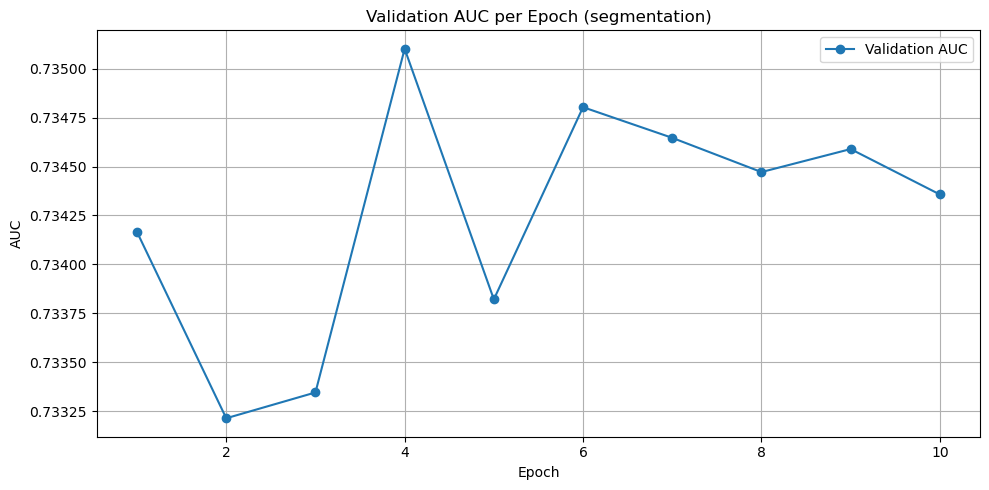

In [11]:
# auc.npy 파일 그래프 그리기
import numpy as np
import matplotlib.pyplot as plt

val_auc_path = "results/seg_val_auc.npy"
val_aucs = np.load(val_auc_path)

# Nan을 제외한 유효한 AUC만 선택
valid_indices = ~np.isnan(val_aucs)
valid_epochs = np.arange(len(val_aucs))[valid_indices]
valid_aucs = val_aucs[valid_indices]

# 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(valid_epochs + 1, valid_aucs, marker='o', label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation AUC per Epoch (segmentation)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# .npy 파일 내용확인
import numpy as np

path = "results/seg_val_auc.npy"
val_auc = np.load(path)
print("validation AUC 배열 길이: " , len(val_auc))
print("validtation AUC 값들 : ", )
print(val_auc)

validation AUC 배열 길이:  16
validtation AUC 값들 : 
[0.7326301  0.73402579 0.73380591 0.73424855 0.73453253 0.73459978
 0.73413067 0.73317175 0.73439537 0.73492732 0.73425098 0.73503479
 0.73463152 0.73436369 0.73483862 0.73447097]


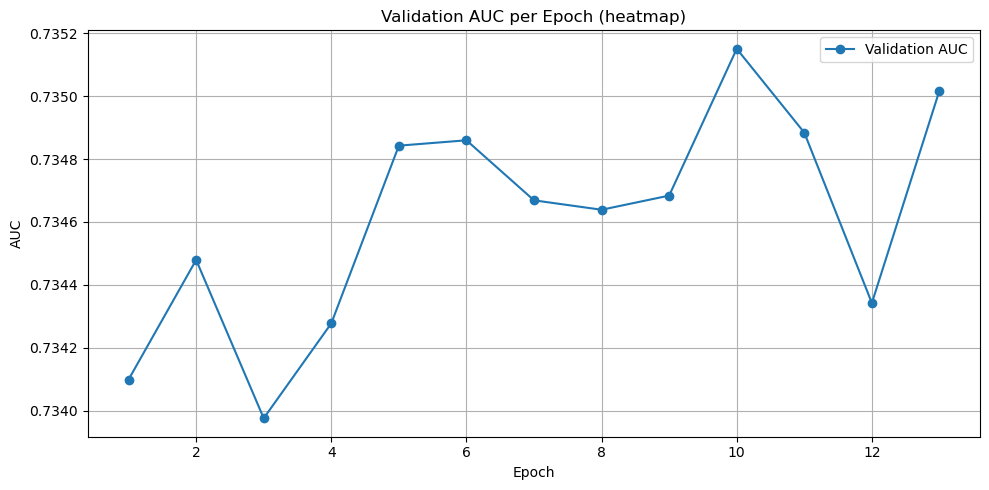

In [12]:
# auc.npy 파일 그래프 그리기
import numpy as np
import matplotlib.pyplot as plt

val_auc_path = "results/heat_val_auc.npy"
val_aucs = np.load(val_auc_path)

# Nan을 제외한 유효한 AUC만 선택
valid_indices = ~np.isnan(val_aucs)
valid_epochs = np.arange(len(val_aucs))[valid_indices]
valid_aucs = val_aucs[valid_indices]

# 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(valid_epochs + 1, valid_aucs, marker='o', label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation AUC per Epoch (heatmap)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

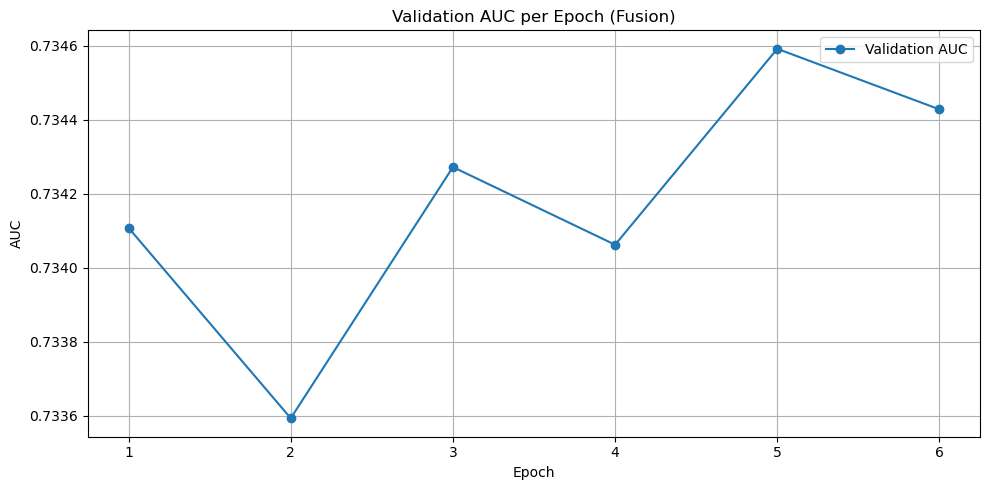

In [10]:
# auc.npy 파일 그래프 그리기
import numpy as np
import matplotlib.pyplot as plt

val_auc_path = "results/fusion_val_auc.npy"
val_aucs = np.load(val_auc_path)

# Nan을 제외한 유효한 AUC만 선택
valid_indices = ~np.isnan(val_aucs)
valid_epochs = np.arange(len(val_aucs))[valid_indices]
valid_aucs = val_aucs[valid_indices]

# 그래프 그리기
plt.figure(figsize=(10, 5))
plt.plot(valid_epochs + 1, valid_aucs, marker='o', label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.title('Validation AUC per Epoch (Fusion)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

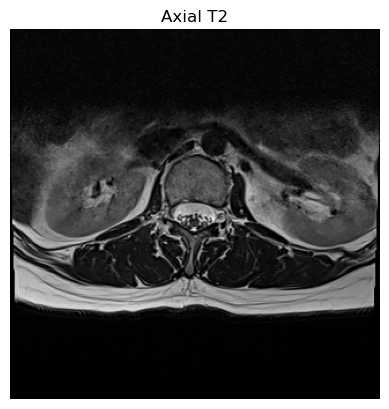

'\n4003253,702807833,Sagittal T2/STIR\n4003253,1054713880,Sagittal T1\n4003253,2448190387,Axial T2\n'

In [30]:
import pydicom
import matplotlib.pyplot as plt

dcm_path = "rsna_2024_spine/train_images/4003253/2448190387/1.dcm"
ds = pydicom.dcmread(dcm_path)

image = ds.pixel_array

plt.imshow(image, cmap='gray')
plt.title('Axial T2')
plt.axis('off')
plt.show()

'''
4003253,702807833,Sagittal T2/STIR
4003253,1054713880,Sagittal T1
4003253,2448190387,Axial T2
'''

In [1]:
import torch
print(torch.cuda.is_available())

True
